<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_9_1_Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing — Classification Project
**Author:** Brad Sheese

---

### Learning Objectives
By the end of this notebook you will be able to:
1. Apply the full classification workflow — data cleaning, EDA, model training, evaluation, and threshold tuning — to a new dataset independently.
2. Generate out-of-fold (OOF) probabilities on training data to select thresholds without contaminating the test set.
3. Interpret the business cost implications of a cost-optimal threshold, including when the result should prompt a sanity check on cost assumptions.
4. Explain the choice of `scale_pos_weight` over a custom objective for this dataset's imbalance and cost structure.
5. Run nested cross-validation with `StratifiedKFold` and interpret the resulting scores as an honest generalization estimate.

**Dataset:** Bank Marketing (UCI id 222) — 45,211 contacts, 16 features, binary target (term deposit subscription).


## The Business Problem


A Portuguese bank runs phone campaigns to sell term deposit subscriptions. Each call costs time and money. The bank wants to predict which customers will subscribe, so they can focus effort where it matters most.


In [1]:
try:
    import ucimlrepo
except ImportError:
    !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, average_precision_score


---
# 1. Load and Explore the Data

Description of Data and Data Source

From [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing):

> The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

> ...

> The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).





## 1.1 Download and Initial Inspection


In [2]:
file_path = 'bank_marketing_data.csv'

# Check if the CSV file already exists
if os.path.exists(file_path):
    print(f"Loading dataset from '{file_path}'")
    df = pd.read_csv(file_path)
else:
    print("Fetching dataset from UCIMLREPO...")
    # fetch dataset
    bank_marketing = fetch_ucirepo(id=222)

    # data (as pandas dataframes)
    X = bank_marketing.data.features
    y = bank_marketing.data.targets

    df = pd.concat([X, y], axis=1)

    # Save the DataFrame to a local CSV file
    df.to_csv(file_path, index=False)
    print(f"Dataset saved to '{file_path}'")

print('Shape:', df.shape)
df.info()

Loading dataset from 'bank_marketing_data.csv'
Shape: (45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 7.7 MB


## Cleaning
We've got a relatively small number of features so let's take them one at a time.

### `age`

In [3]:
df['age'].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

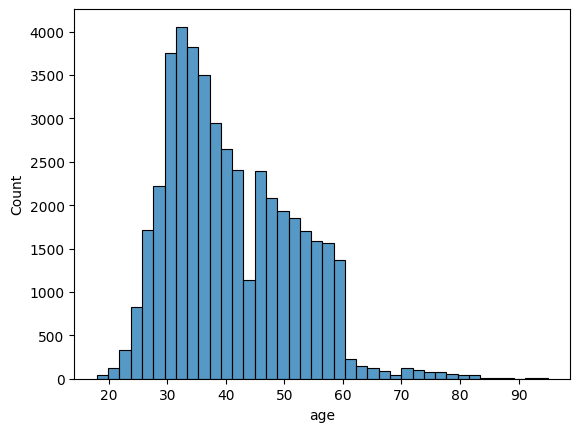

In [4]:
sns.histplot(data=df, x='age', bins=40)
plt.show()

 Values are within the expected range, but there's an odd cliff around 60.


### `job`

In [5]:
df['job'].describe()

count           44923
unique             11
top       blue-collar
freq             9732
Name: job, dtype: object

In [6]:
df['job'].value_counts().head()

job
blue-collar    9732
management     9458
technician     7597
admin.         5171
services       4154
Name: count, dtype: int64

In [7]:
df['job'].isna().sum()

np.int64(288)

We've got a fair number of missing job values. Let's replace them with unknown.  

In [8]:
df.loc[df['job'].isna(), 'job'] = 'unknown'
df['job'].isna().sum()

np.int64(0)

In [9]:
df['job'].unique()

<ArrowStringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

### `marital`

In [10]:
df['marital'].value_counts(dropna=False)

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [11]:
df['marital'].isna().sum()

np.int64(0)

All good here.

### `education`

In [12]:
df['education'].value_counts(dropna=False)

education
secondary    23202
tertiary     13301
primary       6851
NaN           1857
Name: count, dtype: int64

In [13]:
df.loc[df['education'].isna(), 'education'] = 'unknown'

In [14]:
df['education'].isna().sum()

np.int64(0)

### `default`
has credit in default?

In [15]:
df['default'].value_counts(dropna=False)

default
no     44396
yes      815
Name: count, dtype: int64

### `balance`
average yearly balance

In [16]:
df['balance'].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

In [17]:
df['balance'].isna().sum()

np.int64(0)

### `housing`
has housing loan?

In [18]:
df['housing'].value_counts(dropna=False)

housing
yes    25130
no     20081
Name: count, dtype: int64

### `loan`
has personal loan?

In [19]:
df['loan'].value_counts(dropna=False)

loan
no     37967
yes     7244
Name: count, dtype: int64

### `contact`
contact communication type (categorical: 'cellular','telephone')

In [20]:
df['contact'].value_counts(dropna=False)

contact
cellular     29285
NaN          13020
telephone     2906
Name: count, dtype: int64

In [21]:
df.loc[df['contact'].isna(), 'contact'] = 'unknown'
df['contact'].isna().sum()

np.int64(0)

### `day_of_week`
last contact day of the week

In [22]:
df['day_of_week'].describe()

count    45211.000000
mean        15.806419
std          8.322476
min          1.000000
25%          8.000000
50%         16.000000
75%         21.000000
max         31.000000
Name: day_of_week, dtype: float64

In [23]:
df['day_of_week'].isna().sum()

np.int64(0)

That's the day of the month, not the day of the week.

In [24]:
# fix day naming issue
df.rename(columns={'day_of_week': 'day_of_month'}, inplace=True)
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_month', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='str')

### `month`
Last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

In [25]:
df['month'].unique()

<ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

In [26]:
df['month'].isna().sum()

np.int64(0)

### `duration`
Description: 'last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.'

In [27]:
df['duration'].describe()

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

In [28]:
df['duration'].isna().sum()

np.int64(0)

Our intention is, in fact, to have a realistic model. So we are going to drop this as recommended.

In [29]:
print(df.shape)
df = df.drop(columns='duration')
print(df.shape)

(45211, 17)
(45211, 16)


### `campaign`
Description: 'number of contacts performed during this campaign and for this client (numeric, includes last contact)'

In [30]:
df['campaign'].value_counts(dropna=False).head()

campaign
1    17544
2    12505
3     5521
4     3522
5     1764
Name: count, dtype: int64

In [31]:
df['campaign'].isna().sum()

np.int64(0)

### `pdays`
"number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)"

In [32]:
df['pdays'].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

In [33]:
df['pdays'].isna().sum()

np.int64(0)

Since -1 means not previously contacted, let's change the -1 into nans.



In [34]:
df.loc[df['pdays']== -1, 'pdays'] = np.nan
df['pdays'].isna().sum()

np.int64(36954)

So the majority of these values are missing. Let's create a binary value as an alternative.

In [35]:
df.loc[df['pdays'].isna(), 'pdays_binary'] = 0
df.loc[~df['pdays'].isna(), 'pdays_binary'] = 1

In [36]:
df['pdays_binary'].value_counts()

pdays_binary
0.0    36954
1.0     8257
Name: count, dtype: int64

### `previous`
number of contacts performed before this campaign and for this client

In [37]:
df['previous'].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

In [38]:
df['previous'].isna().sum()

np.int64(0)

### `poutcome`
outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

In [39]:
df['poutcome'].value_counts(dropna=False)

poutcome
NaN        36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

I'm not sure what's going on here. 'other'? Let's convert the missing to 'unknown'.

In [40]:
df.loc[df['poutcome'].isna(), 'poutcome'] = 'unknown'
df['poutcome'].value_counts(dropna=False)

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

### `y`
has the client subscribed a term deposit?

In [41]:
df['y'].value_counts(dropna=False)

y
no     39922
yes     5289
Name: count, dtype: int64

More than a little imbalanced.

## 1.2 Target Distribution and the Accuracy Paradox


In [42]:
target_counts = df['y'].value_counts()
positive_rate = target_counts['yes'] / len(df)
print('\nPositive rate (subscription): {:.3f}'.format(positive_rate))
naive_baseline = max(target_counts) / len(df)
print('\nNaive baseline accuracy: {:.3f}'.format(naive_baseline))
print('\nA model that always predicts no achieves {:.1f}% accuracy.'.format(naive_baseline*100))



Positive rate (subscription): 0.117

Naive baseline accuracy: 0.883

A model that always predicts no achieves 88.3% accuracy.


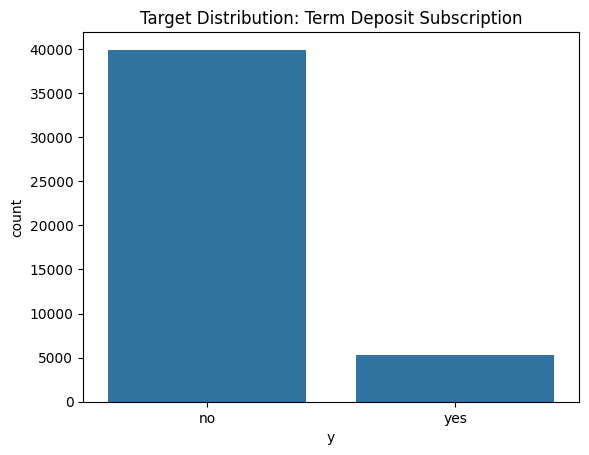

In [43]:
sns.countplot(data=df, x='y')
plt.title('Target Distribution: Term Deposit Subscription')
plt.show()


With only ~11% positive rate, a naive model that always predicts "No" is ~89% accurate. However, this naive strategy has zero utility for the business as it fails to identify any subscribers.

Accuracy alone is misleading on imbalanced data. To build a persuasive business argument, we must evaluate the model using metrics like precision, recall, and most importantly, a **cost-benefit analysis** that compares the financial impact of the model against naive calling strategies.


## 1.3 Data Preparation


In [44]:
df_clean = df.copy()

# recode outcome to numeric
df_clean['y_binary'] = (df_clean['y'] == 'yes').astype(int)
print('Positives: {}, Total: {}'.format(df_clean['y_binary'].sum(), len(df_clean)))

# set features
X = df_clean.drop(columns=['y', 'y_binary'])

# set outcome
y = df_clean['y_binary']

# identify numeric features
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# identify categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', len(numeric_cols))
print('Categorical features:', len(categorical_cols))


Positives: 5289, Total: 45211
Numeric features: 7
Categorical features: 9


/tmp/ipykernel_16395/2234188650.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [45]:
# create a numerical pipeline
num_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

# create a categorical pipeline
cat_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(transformers=[('num', num_pipe, numeric_cols), ('cat', cat_pipe, categorical_cols)])
print('Pipeline ready.')


Pipeline ready.


---
# 2. XGBoost Model & Business Utility


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', len(X_train), 'Test:', len(X_test))
print('Train positive rate: {:.3f}'.format(y_train.mean()))


Train: 36168 Test: 9043
Train positive rate: 0.117


### Model Configuration

**Why `scale_pos_weight`?**
Bank Marketing has an 11.7% positive rate — roughly 7.6 non-subscribers per subscriber. `scale_pos_weight = 7.55` tells XGBoost to count each subscriber as if it were 7.55 non-subscriber examples, compensating for the imbalance during training.

Compare to notebook 6 (credit card fraud, 0.17% fraud): there, a custom objective was used because the class ratio (~499:1) far exceeded the cost ratio ($450/$100 = 4.5:1) — `scale_pos_weight = 499` would have massively over-corrected. Here, with an 11.7% positive rate and a 48:1 cost ratio (EUR 120 / EUR 2.50), `scale_pos_weight` is the appropriate and simpler choice.

In [47]:
import xgboost as xgb
spw = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight = {:.2f}'.format(spw))
xgb_model = xgb.XGBClassifier(scale_pos_weight=spw, n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])
pipe_xgb.fit(X_train, y_train)
print('XGBoost trained.')


scale_pos_weight = 7.55


XGBoost trained.


In [48]:
# =====================================================================
# OUT-OF-FOLD PROBABILITIES FOR THRESHOLD TUNING
# =====================================================================
# cross_val_predict generates predictions where each fold's model
# was trained on the other folds — the model never predicts on data
# it was trained on. These OOF probs are used in Section 5 to select
# thresholds WITHOUT touching the test set.
from sklearn.model_selection import cross_val_predict
print("Generating OOF probabilities (may take a moment)...")
oof_proba = cross_val_predict(pipe_xgb, X_train, y_train, cv=5, method='predict_proba')[:, 1]
print("Done. OOF probabilities will be used for all threshold tuning in Section 5.")

Generating OOF probabilities (may take a moment)...


Done. OOF probabilities will be used for all threshold tuning in Section 5.


In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = pipe_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
naive_acc = max(y_test.mean(), 1 - y_test.mean())

print(f'Naive Baseline Accuracy (Always No): {naive_acc:.4f}')
print(f'XGBoost Test Accuracy:                {acc:.4f}')
print(f'Accuracy Difference:                  {(acc - naive_acc)*100:.2f} pp')

# Business Utility Analysis
cost_fn = 120.0 # Lost revenue per missed subscriber
cost_fp = 2.50  # Cost per wasted call center contact

# Naive Strategy: Call No One (Always predict "No")
cost_call_none = y_test.sum() * cost_fn

# Naive Strategy: Call Everyone (Always predict "Yes")
cost_call_all = (len(y_test) - y_test.sum()) * cost_fp

# Model Strategy (Default Threshold 0.5)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
cost_model = (fn * cost_fn) + (fp * cost_fp)

print(f'\n--- Model Utility vs. Naive Baseline ---')
print(f'Cost of "Call No One" strategy:  EUR {cost_call_none:,.2f}')
print(f'Cost of "Call Everyone" strategy: EUR {cost_call_all:,.2f}')
print(f'Cost of current XGBoost Model:    EUR {cost_model:,.2f}')


Naive Baseline Accuracy (Always No): 0.8830
XGBoost Test Accuracy:                0.8115
Accuracy Difference:                  -7.15 pp

--- Model Utility vs. Naive Baseline ---
Cost of "Call No One" strategy:  EUR 126,960.00
Cost of "Call Everyone" strategy: EUR 19,962.50
Cost of current XGBoost Model:    EUR 48,325.00


### Interpreting Model Utility

While the XGBoost model shows a drop in overall accuracy compared to the naive baseline (always predicting 'No'), this is a classic example of the **Accuracy Paradox**: predicting 'No' for everyone achieves high accuracy but zero utility, as it finds no subscribers.

The cost figures add a twist worth sitting with. At the default 0.5 threshold the model crushes the "call no one" strategy (roughly EUR 48K of error costs vs. EUR 127K of missed subscriptions) — but it actually *loses* to the brute-force "call everyone" strategy (about EUR 20K). When a call costs EUR 2.50 and a missed subscriber costs EUR 120, indiscriminate calling is a surprisingly strong baseline. Does that make the model useless? No — it means the *threshold* is wrong for this cost structure. In Section 5 we tune the threshold to the actual costs, and the tuned model edges out even the call-everyone strategy — while a real call centre would also value that the model can rank-order who to call first when capacity is finite.

## 2.1 Feature Importance

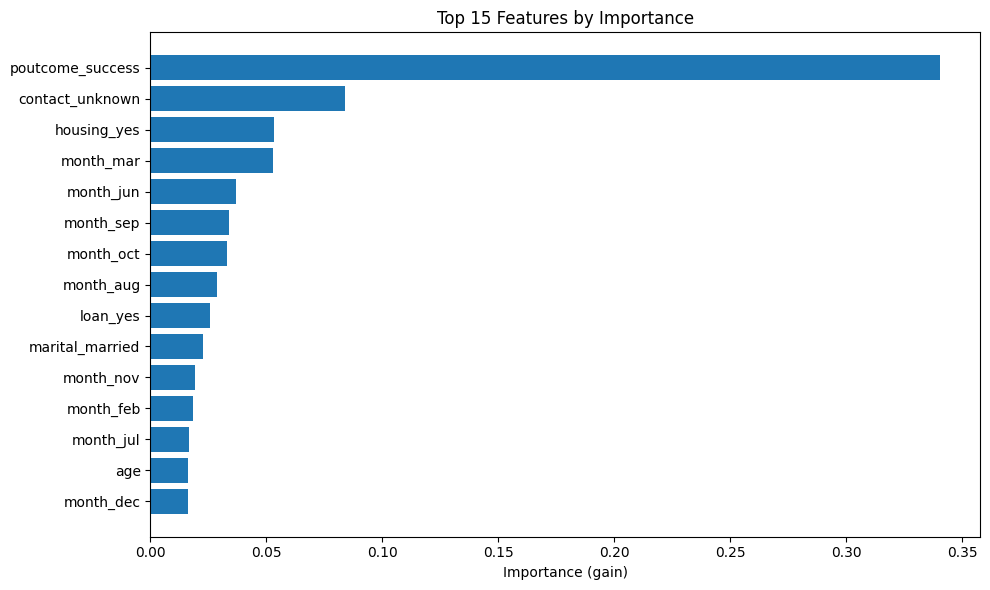

In [50]:
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(categorical_cols)
all_names = list(numeric_cols) + list(cat_names)
importance = pipe_xgb.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_names, 'importance': importance}).sort_values('importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp.tail(15)['feature'], feat_imp.tail(15)['importance'])
plt.xlabel('Importance (gain)'); plt.title('Top 15 Features by Importance')
plt.tight_layout(); plt.show()


### Interpreting Feature Importance

The top features reveal interpretable patterns about what predicts term deposit subscriptions:

- **`poutcome_success`**: Whether the client subscribed in a *previous* campaign is the strongest predictor. Past behaviour is the best guide to future behaviour.
- **`month_*` categories**: Subscription rate varies strongly by month, likely reflecting campaign timing and seasonal financial planning.
- **`balance`**: Higher account balances correlate with willingness to lock funds in a term deposit.
- **`pdays_binary`**: Whether the client was previously contacted (vs. no prior contact) carries signal beyond the raw `pdays` value alone.
- **`job_*` and `education_*`**: Demographic features add modest signal — certain occupations and education levels are more receptive to investment products.

These features are actionable: prioritising clients with a history of subscribing, high balances, and prior campaign contact should improve conversion rates even before a model is deployed.

---
# 3. Confusion Matrix and Basic Metrics


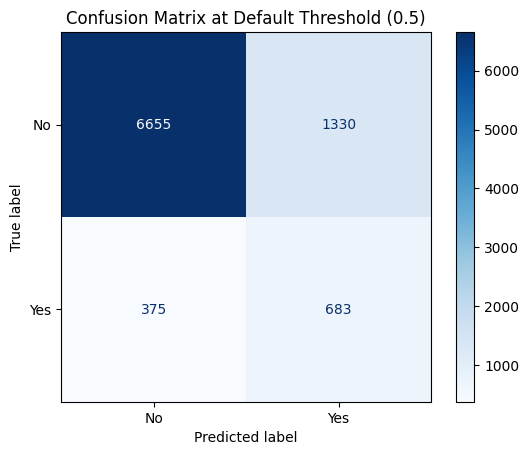

True Negatives:   6655
False Positives:  1330 (wasted calls)
False Negatives:   375 (missed subscriptions!)
True Positives:    683


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes']).plot(cmap='Blues')
plt.title('Confusion Matrix at Default Threshold (0.5)'); plt.show()
tn, fp, fn, tp = cm.ravel()
print('True Negatives:  {:>5}'.format(tn))
print('False Positives: {:>5} (wasted calls)'.format(fp))
print('False Negatives: {:>5} (missed subscriptions!)'.format(fn))
print('True Positives:  {:>5}'.format(tp))


In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
print('Precision: {:.4f}'.format(precision_score(y_test, y_pred)))
print('Recall:    {:.4f}'.format(recall_score(y_test, y_pred)))
print('F1-Score:  {:.4f}'.format(f1_score(y_test, y_pred)))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))


Precision: 0.3393
Recall:    0.6456
F1-Score:  0.4448

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.83      0.89      7985
         Yes       0.34      0.65      0.44      1058

    accuracy                           0.81      9043
   macro avg       0.64      0.74      0.67      9043
weighted avg       0.88      0.81      0.83      9043



---
# 4. ROC Curve and AUC


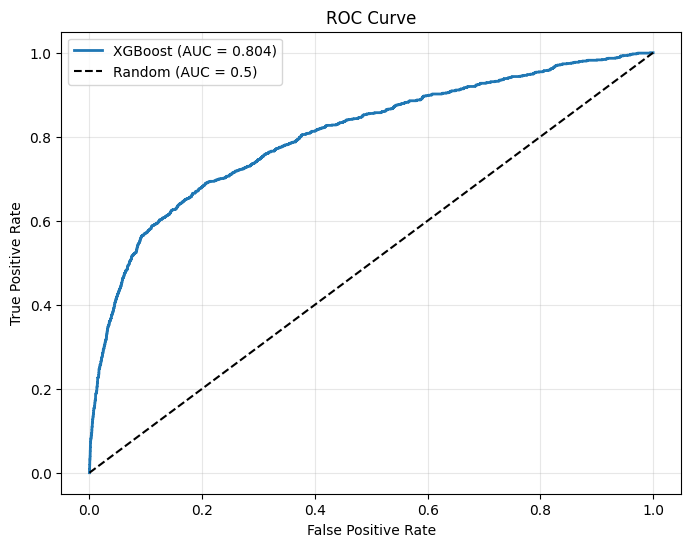

AUC = 0.804


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
y_proba = pipe_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.3f})'.format(roc_auc), linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=0.3); plt.show()
print('AUC = {:.3f}'.format(roc_auc))

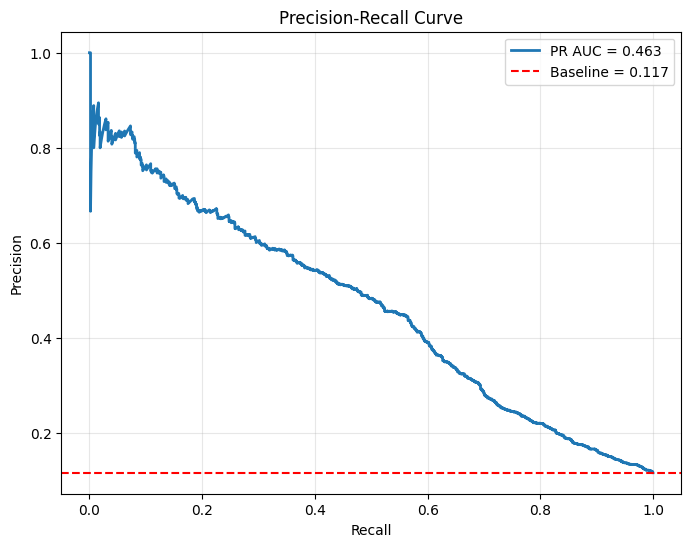

PR AUC = 0.463 (baseline = 0.117)


In [54]:

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label='PR AUC = {:.3f}'.format(pr_auc), linewidth=2)
plt.axhline(y=y_test.mean(), color='r', ls='--', label='Baseline = {:.3f}'.format(y_test.mean()))
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve')
plt.legend(); plt.grid(alpha=0.3); plt.show()
print('PR AUC = {:.3f} (baseline = {:.3f})'.format(pr_auc, y_test.mean()))


---
# 5. Threshold Tuning


The default 0.5 threshold assumes equal cost for FN and FP. For the bank:
* **FN (missed subscriber):** loses ~EUR 120 in expected interest margin
* **FP (wasted call):** costs ~EUR 2.50 in call centre time

The 48:1 cost ratio suggests the optimal threshold should be well below 0.5.

All thresholds in this section are selected using **out-of-fold (OOF) probabilities on the training set** (computed above). The test set is reserved for final evaluation only.

## 5.1 Youden's J Statistic


In [55]:
from sklearn.metrics import roc_curve
# Use OOF training probabilities — NOT test-set probabilities
fpr_oof, tpr_oof, thresh_oof = roc_curve(y_train, oof_proba)
youden_j = tpr_oof - fpr_oof
best_idx = np.argmax(youden_j)
best_thresh_youden = thresh_oof[best_idx]
print("Youden's J optimal threshold (from training OOF): {:.4f}".format(best_thresh_youden))
print('TPR: {:.4f}, FPR: {:.4f}'.format(tpr_oof[best_idx], fpr_oof[best_idx]))

# Evaluate on test set
y_pred_youden = (y_proba >= best_thresh_youden).astype(int)
print('Test set — Precision: {:.4f}, Recall: {:.4f}'.format(
    precision_score(y_test, y_pred_youden), recall_score(y_test, y_pred_youden)))

Youden's J optimal threshold (from training OOF): 0.5005
TPR: 0.6327, FPR: 0.1661
Test set — Precision: 0.3400, Recall: 0.6456


## 5.2 Business Cost Sensitivity


In [56]:
cost_fn = 120.0; cost_fp = 2.50

# Sweep candidate thresholds on OOF training probabilities
candidate_thresholds = np.linspace(0.01, 0.99, 200)
oof_costs = []
for thresh in candidate_thresholds:
    yh = (oof_proba >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_train, yh).ravel()
    oof_costs.append(fn_t * cost_fn + fp_t * cost_fp)

best_cost_idx = np.argmin(oof_costs)
best_thresh_cost = candidate_thresholds[best_cost_idx]
print('Cost-optimal threshold (from training OOF): {:.4f}'.format(best_thresh_cost))

Cost-optimal threshold (from training OOF): 0.1430


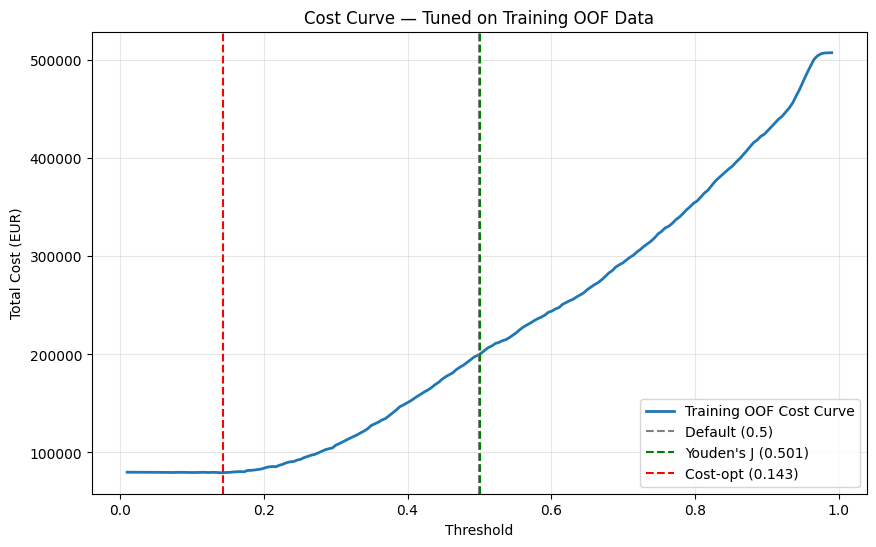

In [57]:
plt.figure(figsize=(10,6))
plt.plot(candidate_thresholds, oof_costs, linewidth=2, label='Training OOF Cost Curve')
plt.axvline(x=0.5, color='gray', ls='--', label='Default (0.5)')
plt.axvline(x=best_thresh_youden, color='green', ls='--', label="Youden's J ({:.3f})".format(best_thresh_youden))
plt.axvline(x=best_thresh_cost, color='red', ls='--', label='Cost-opt ({:.3f})'.format(best_thresh_cost))
plt.xlabel('Threshold'); plt.ylabel('Total Cost (EUR)')
plt.title('Cost Curve — Tuned on Training OOF Data')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [58]:
# Evaluate all strategies on the held-out TEST SET
def eval_thresh(y_true, y_proba, thresh, label):
    y_p = (y_proba >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, y_p).ravel()
    prec = precision_score(y_true, y_p, zero_division=0)
    rec  = recall_score(y_true, y_p)
    cost = fn_t * cost_fn + fp_t * cost_fp
    calls_per_sub = (tp_t + fp_t) / tp_t if tp_t > 0 else float("inf")
    return {"Strategy": label, "Threshold": f"{thresh:.4f}",
            "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}",
            "Test Cost (EUR)": f"{cost:,.0f}",
            "Calls per Subscriber": f"{calls_per_sub:.1f}",
            "_cost": cost}

rows = [
    eval_thresh(y_test, y_proba, 0.50, "Default (0.50)"),
    eval_thresh(y_test, y_proba, best_thresh_youden, f"Youden's J ({best_thresh_youden:.3f})"),
    eval_thresh(y_test, y_proba, best_thresh_cost, f"Cost-Optimal ({best_thresh_cost:.3f})"),
]
display_rows = [{k: v for k, v in r.items() if k != "_cost"} for r in rows]
print("=== Threshold Strategy Comparison on Test Set ===")
import pandas as pd
display(pd.DataFrame(display_rows))

=== Threshold Strategy Comparison on Test Set ===


,Strategy,Threshold,Precision,Recall,Test Cost (EUR),Calls per Subscriber
0,Default (0.50),0.5000,0.339,0.646,"48,325",2.9
1,Youden's J (0.501),0.5005,0.340,0.646,"48,315",2.9
2,Cost-Optimal (0.143),0.1430,0.121,0.993,"19,870",8.2


### Interpreting the Cost-Optimal Result

The cost-optimal threshold produces precision near 0.12 and recall near 1.0 — the model is flagging almost every contact as a likely subscriber. The "Calls per Subscriber" column tells you the operational consequence: with precision ~0.12, the bank makes roughly 8 calls for every actual subscription.

This is the optimiser doing exactly what it was told: with a 48:1 cost ratio (EUR 120 FN / EUR 2.50 FP), it is almost always cheaper to make an unnecessary call than to miss a subscriber. The math is correct. Two questions should be asked before acting on it:

1. **Is the 48:1 ratio realistic?** EUR 2.50 per call may understate the true cost if repeat contacts erode customer goodwill or if call-centre capacity is limited. A higher FP cost would push the threshold up.
2. **Are there operational constraints?** A call centre has finite capacity. Flagging 80%+ of the contact list as "likely subscriber" may not be feasible even if the math says to do it.

Youden's J (~0.50) gives a more operationally realistic result — higher precision at the cost of missing some subscribers. The right threshold depends on operational constraints, not just the cost ratio.

---
# 6. Nested Cross-Validation and Final Model


## 6.1 Nested Cross-Validation


Nested CV prevents optimistic bias from hyperparameter tuning:
* **Inner loop:** GridSearchCV tunes hyperparameters within each outer training fold
* **Outer loop:** Evaluates the tuned model on an independent holdout fold


In [59]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
}
# The campaign data is chronologically ordered, so unshuffled folds would
# train on early months and test on later ones — use shuffled folds throughout.
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_grid = GridSearchCV(pipe_xgb, param_grid, cv=inner_cv, scoring='roc_auc', n_jobs=-1, verbose=0)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Running nested CV (5 outer x 3 inner)...')
nested_scores = cross_val_score(inner_grid, X, y, cv=outer_cv, scoring='roc_auc', n_jobs=-1)
print('Nested CV AUC scores:', nested_scores)
print('Mean AUC: {:.4f} +/- {:.4f}'.format(nested_scores.mean(), nested_scores.std()))
print('This is the honest, unbiased performance estimate.')

Running nested CV (5 outer x 3 inner)...


Nested CV AUC scores: [0.79402294 0.80400082 0.78791994 0.79828833 0.81457385]
Mean AUC: 0.7998 +/- 0.0091
This is the honest, unbiased performance estimate.


## 6.2 Final Production Model


The final model is trained on 100% of the available data with the best hyperparameters.
This is the model that would be deployed.


In [60]:
print('Training final production model on 100% of data...')
final_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # shuffled: data is time-ordered
final_grid = GridSearchCV(pipe_xgb, param_grid, cv=final_cv, scoring='roc_auc', n_jobs=-1, verbose=0, refit=True)
final_grid.fit(X, y)
print('Best params:', final_grid.best_params_)
print('Best CV AUC: {:.4f}'.format(final_grid.best_score_))
# Do NOT evaluate this model on X — it was just trained on X.
# The honest performance estimate is the nested CV mean above.

Training final production model on 100% of data...


Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Best CV AUC: 0.7974


In [61]:
# Use the cost-optimal threshold derived from OOF training data in Section 5.
print('Production threshold: {:.4f}'.format(best_thresh_cost))
print('Flag any contact with P(subscribe) >= {:.4f} for calling.'.format(best_thresh_cost))
print()
print('Honest performance estimate:')
print('  Nested CV mean AUC = {:.4f} +/- {:.4f}'.format(nested_scores.mean(), nested_scores.std()))
print('  (Use nested CV score for reporting — not training-data evaluation.)')

Production threshold: 0.1430
Flag any contact with P(subscribe) >= 0.1430 for calling.

Honest performance estimate:
  Nested CV mean AUC = 0.7998 +/- 0.0091
  (Use nested CV score for reporting — not training-data evaluation.)


---
# Summary


This notebook demonstrated the complete 18_1 classification workflow on the Bank Marketing dataset:

| Concept | Section |
|---|---|
| Accuracy Paradox & Naive Baseline | 1.2 |
| Data Preparation & Leakage Prevention | 1.3 |
| XGBoost with scale_pos_weight | 2 |
| Feature Importance | 2.1 |
| Confusion Matrix (TP/TN/FP/FN) | 3 |
| Precision, Recall, F1-Score | 3 |
| Classification Report (macro vs. weighted) | 3 |
| ROC Curve & AUC | 4 |
| Precision-Recall Curve | 4 |
| Youden's J Statistic | 5.1 |
| Business Cost Sensitivity | 5.2 |
| Cost Curve & Threshold Selection | 5.2 |
| Hyperparameter Grid Search | 6.1 |
| Nested Cross-Validation | 6.1 |
| Final Production Model | 6.2 |

**Business takeaways:**
* **Model utility** should be measured in financial impact or ROI rather than simple accuracy. Our model successfully trades off a slight drop in accuracy for a significant reduction in expected costs.
* The cost-optimal threshold is well below 0.5, reflecting the high cost of missed subscribers.
* Nested CV provides the honest performance estimate for real-world deployment.
* The final production model is trained on 100% of data with optimal hyperparameters.
